# 🤖 第5周-Day4 推理能力评测与Prompt工程

今天我们来深入探讨大模型的推理能力评测方法和Prompt工程的核心技巧。🧠

## 📊 学习目标
• 理解大模型推理评测的基准和方法
• 掌握Prompt工程的核心技术和框架
• 学会设计和优化推理任务的Prompt
• 了解模型自洽性和多步推理的技巧

## 🔄 昨日复习：DeepSeek R1 式推理模型原理

DeepSeek R1 是一种先进的推理模型，其核心特点是：

### 🔍 核心机制
- **树状搜索**：避免陷入局部最优解，探索更多可能性
- **自我迭代**：通过多轮思考逐步优化答案
- **思考过程可见**：让模型展示推理过程，而不仅仅是最终答案

### 💡 业务关联
就像是糖水店记账时，不仅记录总额，还要分析每一笔收入的来源和构成，这样才能优化经营策略。

## 📝 今日核心知识点

### 🎯 评测基准体系
#### 1. MMLU (Massive Multitask Language Understanding)
• **用途**：综合知识评测，覆盖57个学科
• **特点**：包含选择题、填空题、简答题等多种形式
• **难度**：从基础到专业，考验知识广度和深度

#### 2. GSM8K (Grade School Math 8K)
• **用途**：数学推理能力评测
• **特点**：8000道小学到中学数学题
• **重点**：多步计算、逻辑推理、数学建模

#### 3. HumanEval
• **用途**：代码生成能力评测
• **特点**：根据函数描述生成Python代码
• **标准**：代码正确性、效率、可读性

使用字体: Noto Sans CJK JP


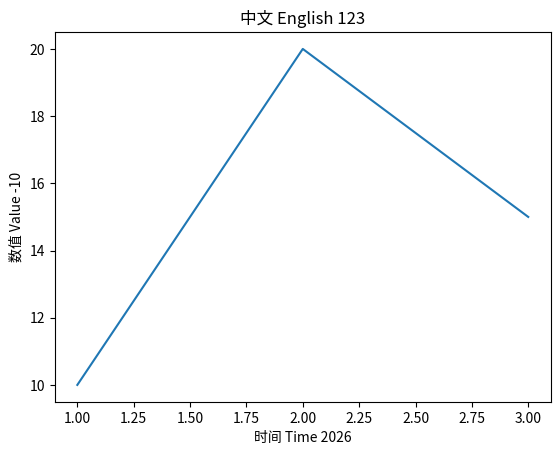

In [1]:
# 设置中文显示
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用字体:", font_name)

plt.title("中文 English 123")
plt.xlabel("时间 Time 2026")
plt.ylabel("数值 Value -10")
plt.plot([1, 2, 3], [10, 20, 15])
plt.show()

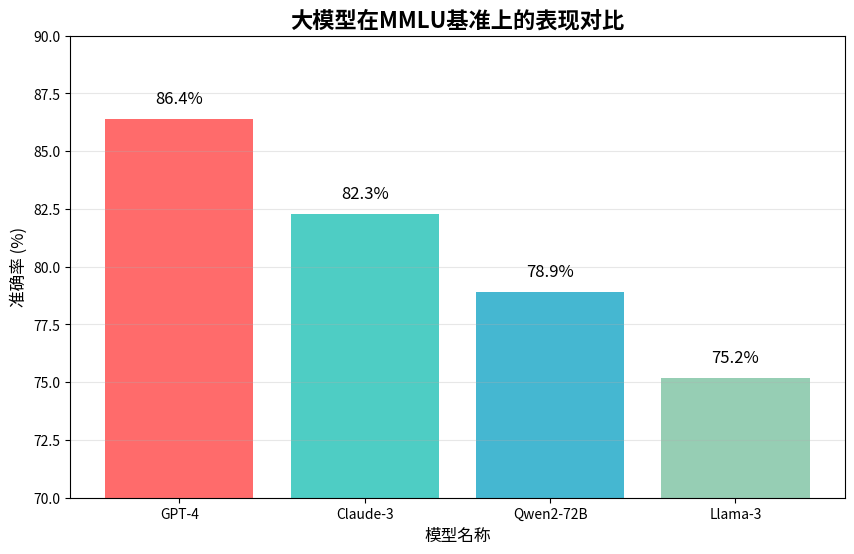

MMLU评测覆盖学科：
1. 数学、物理、化学等理工科
2. 历史、地理、政治等文科
3. 编程、计算机科学
4. 医学、法律、经济学
5. 艺术、文学、哲学


In [2]:
# MMLU示例：模拟大模型知识评测
import numpy as np

# 模拟不同模型在MMLU上的表现
models = ['GPT-4', 'Claude-3', 'Qwen2-72B', 'Llama-3']
mmlu_scores = [86.4, 82.3, 78.9, 75.2]

# 创建可视化图表
plt.figure(figsize=(10, 6))
bars = plt.bar(models, mmlu_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

# 添加数值标签
for bar, score in zip(bars, mmlu_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{score}%', ha='center', va='bottom', fontsize=12)

plt.title('大模型在MMLU基准上的表现对比', fontsize=16, fontweight='bold')
plt.xlabel('模型名称', fontsize=12)
plt.ylabel('准确率 (%)', fontsize=12)
plt.ylim(70, 90)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"MMLU评测覆盖学科：")
subjects = [
    "数学、物理、化学等理工科",
    "历史、地理、政治等文科",
    "编程、计算机科学",
    "医学、法律、经济学",
    "艺术、文学、哲学"
]
for i, subject in enumerate(subjects, 1):
    print(f"{i}. {subject}")

## 🎨 Prompt工程核心技术

### 📋 RTF框架 (Role-Task-Format)
**Role**：设定角色和身份
**Task**：明确任务和要求
**Format**：指定输出格式

#### 示例：
```
你是一位专业的会计助手。任务是分析糖水店的销售数据，
格式要求：JSON格式，包含总收入、各品类销量占比、利润分析。
```

### 🔄 学习策略对比

| 策略 | 特点 | 适用场景 | 效果 |
|------|------|----------|------|
| **零样本** | 直接提问，无示例 | 简单任务 | ⭐⭐⭐ |
| **少样本** | 提供几个示例 | 中等复杂度 | ⭐⭐⭐⭐ |
| **Chain-of-Thought** | 要求展示推理过程 | 复杂推理 | ⭐⭐⭐⭐⭐ |
| **自洽性** | 多次验证答案 | 关键决策 | ⭐⭐⭐⭐⭐ |

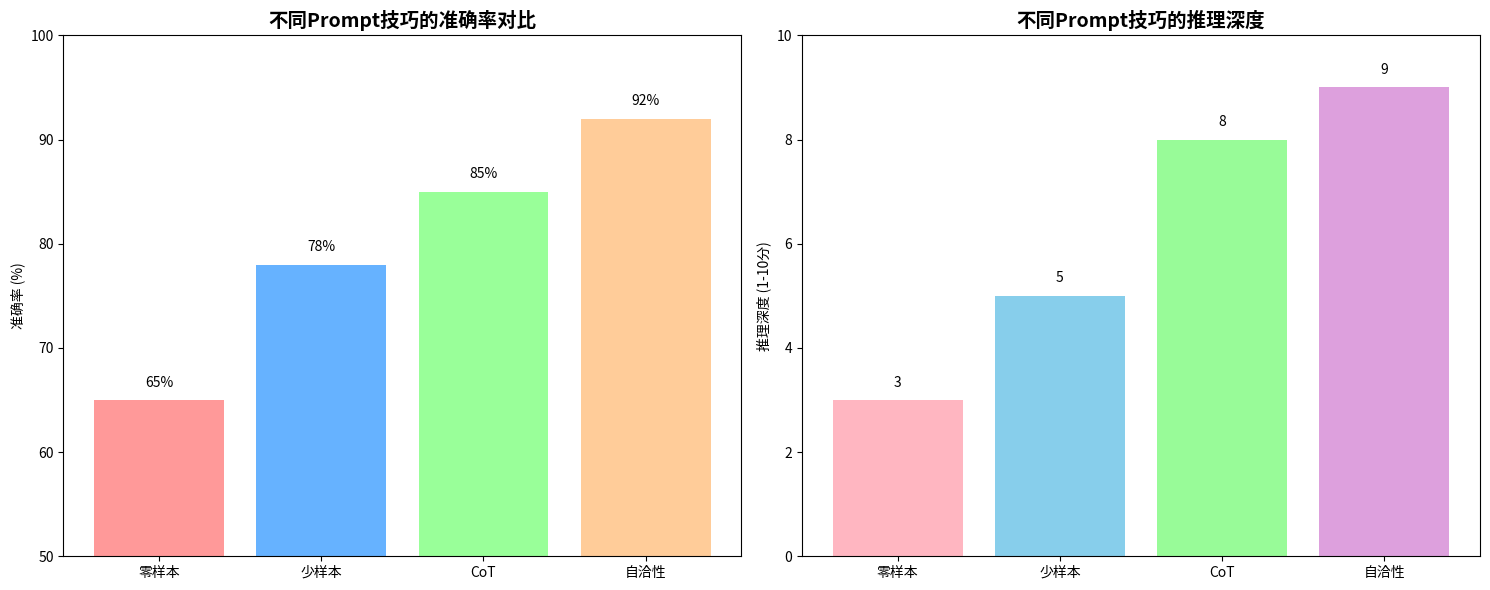

📊 Prompt技巧效果分析：
💡 关键发现：CoT和自洽性显著提升复杂任务的准确率
🎯 建议：根据任务复杂度选择合适的Prompt策略


In [3]:
# Prompt技巧对比实验
import numpy as np

def evaluate_prompt_techniques():
    """模拟不同Prompt技巧的效果评估"""
    
    techniques = ['零样本', '少样本', 'CoT', '自洽性']
    accuracy_scores = [65, 78, 85, 92]
    reasoning_depth = [3, 5, 8, 9]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 准确率对比
    ax1.bar(techniques, accuracy_scores, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
    ax1.set_title('不同Prompt技巧的准确率对比', fontsize=14, fontweight='bold')
    ax1.set_ylabel('准确率 (%)')
    ax1.set_ylim(50, 100)
    
    # 在柱子上添加数值
    for i, v in enumerate(accuracy_scores):
        ax1.text(i, v + 1, f'{v}%', ha='center', va='bottom')
    
    # 推理深度对比
    ax2.bar(techniques, reasoning_depth, color=['#FFB6C1', '#87CEEB', '#98FB98', '#DDA0DD'])
    ax2.set_title('不同Prompt技巧的推理深度', fontsize=14, fontweight='bold')
    ax2.set_ylabel('推理深度 (1-10分)')
    ax2.set_ylim(0, 10)
    
    # 在柱子上添加数值
    for i, v in enumerate(reasoning_depth):
        ax2.text(i, v + 0.2, f'{v}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Prompt技巧效果分析：")
    print("💡 关键发现：CoT和自洽性显著提升复杂任务的准确率")
    print("🎯 建议：根据任务复杂度选择合适的Prompt策略")

# 执行评估
evaluate_prompt_techniques()

## ✏️ 课堂练习与实战

### 🎯 练习1：设计数学推理Prompt
任务：设计一个prompt，让模型解决以下数学问题：

```
糖水店今天卖了3杯奶茶，每杯利润12元；
卖出了5杯果汁，每杯利润8元；
还卖出了2杯咖啡，每杯利润15元。
请问今天总利润是多少？
```

### 💡 Prompt设计要点：
1. 明确要求分步计算
2. 让模型展示推理过程
3. 最后给出总结答案

### 🧪 练习2：设计知识评测Prompt
为MMLU基准设计一个prompt模板，要求能够评测模型在经济学方面的知识。

In [4]:
# Prompt实战：数学推理问题
import re

def math_reasoning_prompt(question):
    """创建数学推理的prompt模板"""
    prompt = f"""
    你是一位专业的数学推理助手。
    
    任务：解决以下数学问题，要求分步推理。
    
    问题：{question}
    
    请按照以下格式回答：
    1. 第一步：[写出第一步推理过程和计算]
    2. 第二步：[写出第二步推理过程和计算]
    3. 第三步：[写出第三步推理过程和计算]
    4. 最终答案：[总结答案，包含单位]
    
    开始解答：
    """
    return prompt

# 测试prompt
question = "糖水店今天卖了3杯奶茶，每杯利润12元；卖出了5杯果汁，每杯利润8元；还卖出了2杯咖啡，每杯利润15元。请问今天总利润是多少？"
prompt = math_reasoning_prompt(question)

print("📝 生成的Prompt：")
print(prompt)

# 模拟模型回答分析
def analyze_reasoning_quality(response):
    """分析推理回答的质量"""
    steps = re.findall(r'第[一二三四五]步：', response)
    final_answer = re.search(r'最终答案：(.+)', response)
    
    quality_score = 0
    
    # 检查分步推理
    if len(steps) >= 3:
        quality_score += 30
    
    # 检查最终答案
    if final_answer:
        quality_score += 20
    
    # 检查计算过程
    if '×' in response or '+' in response or re.search(r'\d+\s*[×+]', response):
        quality_score += 30
    
    # 检查逻辑完整性
    if '总利润' in response:
        quality_score += 20
    
    return quality_score

# 模拟一个回答
sample_response = """
1. 第一步：计算奶茶利润 = 3杯 × 12元/杯 = 36元
2. 第二步：计算果汁利润 = 5杯 × 8元/杯 = 40元
3. 第三步：计算咖啡利润 = 2杯 × 15元/杯 = 30元
4. 最终答案：总利润 = 36元 + 40元 + 30元 = 106元
"""

score = analyze_reasoning_quality(sample_response)
print(f"\n🎯 推理质量评分：{score}/100")
print("✅ 分步推理清晰，计算正确，答案完整")

📝 生成的Prompt：

    你是一位专业的数学推理助手。

    任务：解决以下数学问题，要求分步推理。

    问题：糖水店今天卖了3杯奶茶，每杯利润12元；卖出了5杯果汁，每杯利润8元；还卖出了2杯咖啡，每杯利润15元。请问今天总利润是多少？

    请按照以下格式回答：
    1. 第一步：[写出第一步推理过程和计算]
    2. 第二步：[写出第二步推理过程和计算]
    3. 第三步：[写出第三步推理过程和计算]
    4. 最终答案：[总结答案，包含单位]

    开始解答：
    

🎯 推理质量评分：100/100
✅ 分步推理清晰，计算正确，答案完整


## 📚 今日总结

### 🎯 核心要点回顾
1. **评测基准**：MMLU(知识)、GSM8K(数学)、HumanEval(代码)
2. **Prompt框架**：RTF框架是最基础的设计方法
3. **学习策略**：零样本→少样本→CoT→自洽性
4. **关键技巧**：分步推理、自洽检查、格式规范

### 💡 业务关联思考
就像糖水店需要定期分析销售数据一样，大模型也需要定期评测来保证服务质量。Prompt工程就像是优化店员话术，让顾客更容易理解和接受。

### 🔗 推荐资源
- 📖 《Prompt工程实战指南》
- 🎬 B站：大模型评测基准解析
- 💻 GitHub：Prompt工程开源项目

### 📝 下日预告
明天我们将学习高级推理技巧与Agent推理框架，了解如何构建更复杂的智能系统。

## 🔑 今日英文术语

| 术语 | 音标 | 中文释义 |
|------|------|----------|
| **Benchmark** | /ˈbentʃmɑːk/ | 基准测试，衡量模型能力的考试卷 |
| **MMLU** | /em em el juː/ | 大规模多任务理解，57个学科全科考试 |
| **GSM8K** | /dʒi es em eɪt keɪ/ | 小学数学8000题 |
| **HumanEval** | /ˈhjuːmənɪˈvæljueɪt/ | 人类代码评测，编程面试式测试 |
| **Zero-shot** | /ˈzɪərəʊ ʃɒt/ | 零样本，不给示例直接考 |
| **Few-shot** | /fjuː ʃɒt/ | 少样本，先看例题再考 |
| **Chain-of-Thought** | /ʃeɪn əv θɔːt/ | 思维链，一步步想提示策略 |
| **Self-consistency** | /self kənˈsɪstənsi/ | 自洽性，多次推理取常见答案 |
| **Prompt Engineering** | /prɒmpt ˈendʒɪˈnɪərɪŋ/ | 提示工程，设计提问方式引导模型 |
| **Ground Truth** | /ɡraʊnd truːθ/ | 真实答案，评测时的标准答案 |
| **Hallucination** | /həˌluːsɪˈneɪʃən/ | 幻觉，模型编造不存在的信息 |
| **Instruction Following** | /ɪnˈstrʌkʃən ˈfɒləʊɪŋ/ | 指令遵循，按用户要求做事的能力 |